# Wine Quality Prediction — Classification

## Project B: Classification with MLflow

The objective of this project is to classify white wines into three quality categories:

- Low: quality ≤ 5
- Medium: quality = 6
- High: quality ≥ 7

The project follows a controlled experimental workflow using MLflow for experiment tracking, model comparison, hyperparameter optimization, and model registration.

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [15]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [16]:
# configurations
RANDOM_STATE = 42

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.25

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "Wine Quality - Classification"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

2026/09/03 23:06:51 INFO mlflow.tracking.fluent: Experiment with name 'Wine Quality - Classification' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5000
Experiment: Wine Quality - Classification
Experiment ID: 2


In [17]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv", sep=";"
    )

## EDA

In [18]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [19]:
def quality_class(quality):
    if quality <= 5:
        return 0
    elif quality == 6:
        return 1
    else:
        return 2

In [20]:
classification_data = data.copy()

classification_data["quality_class"] = (
    classification_data["quality"]
    .apply(quality_class)
)

classification_data[
    ["quality", "quality_class"]
].head(10)

,quality,quality_class
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1
5,6,1
6,6,1
7,6,1
8,6,1
9,6,1


In [21]:
CLASS_NAMES = [
    "Low",
    "Medium",
    "High"
]

In [22]:
class_distribution = (
    classification_data["quality_class"]
    .value_counts()
    .sort_index()
)

class_distribution

quality_class
0    1640
1    2198
2    1060
Name: count, dtype: int64

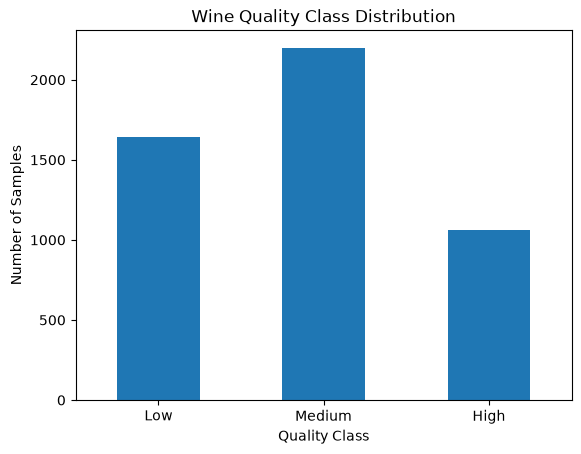

In [23]:
fig, ax = plt.subplots()

class_distribution.plot(
    kind="bar",
    ax=ax
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=0
)

ax.set_xlabel("Quality Class")
ax.set_ylabel("Number of Samples")
ax.set_title("Wine Quality Class Distribution")

plt.show()

In [24]:
X = classification_data.drop(
    columns=[
        "quality",
        "quality_class"
    ]
)

y = classification_data[
    "quality_class"
]

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2938, 11)
Validation: (980, 11)
Test: (980, 11)


In [25]:
for name, target in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:
    print(name)
    print(
        target.value_counts(
            normalize=True
        ).sort_index()
    )
    print()

Train
quality_class
0    0.334922
1    0.448604
2    0.216474
Name: proportion, dtype: float64

Validation
quality_class
0    0.334694
1    0.448980
2    0.216327
Name: proportion, dtype: float64

Test
quality_class
0    0.334694
1    0.448980
2    0.216327
Name: proportion, dtype: float64



In [26]:
def classification_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

## Experiment 00 — Dummy Classifier

This experiment establishes a baseline for the classification task using a Dummy Classifier.

The model always predicts the most frequent class in the training data. Its performance represents the minimum benchmark that subsequent classification models should outperform.

Model selection is based primarily on validation Macro F1.

In [28]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

with mlflow.start_run(run_name="00-DummyClassifier"):

    start_time = time.time()

    dummy_model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start_time

    train_predictions = dummy_model.predict(
        X_train
    )

    prediction_start = time.time()

    val_predictions = dummy_model.predict(
        X_val
    )

    prediction_time = time.time() - prediction_start

    train_metrics = classification_metrics(
        y_train,
        train_predictions
    )

    val_metrics = classification_metrics(
        y_val,
        val_predictions
    )

    mlflow.log_params({
        "strategy": "most_frequent",
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE
    })

    mlflow.log_metrics({
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_f1_weighted": train_metrics["f1_weighted"],

        "validation_accuracy": val_metrics["accuracy"],
        "validation_precision_macro": val_metrics["precision_macro"],
        "validation_recall_macro": val_metrics["recall_macro"],
        "validation_f1_macro": val_metrics["f1_macro"],
        "validation_f1_weighted": val_metrics["f1_weighted"],

        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project B - Classification",
        "model_type": "DummyClassifier",
        "model_family": "Baseline",
        "dataset": "White Wine Quality",
        "task": "Classification",
        "tuning_method": "None"
    })

    cm = confusion_matrix(
        y_val,
        val_predictions,
        labels=[0, 1, 2]
    )

    fig, ax = plt.subplots()

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    display.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        "Dummy Classifier — Validation Confusion Matrix"
    )

    mlflow.log_figure(
        fig,
        "plots/confusion_matrix.png"
    )

    plt.close(fig)
    report = classification_report(
        y_val,
        val_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(
        report
    ).transpose()

    mlflow.log_table(
        report_df.reset_index(),
        "evaluation/classification_report.json"
    )

    input_example = X_train.head(5)

    example_prediction = dummy_model.predict(
        input_example
    )

    signature = infer_signature(
        input_example,
        example_prediction
    )

    mlflow.sklearn.log_model(
        sk_model=dummy_model,
        name="dummy_classifier",
        signature=signature,
        input_example=input_example
    )

    print("Dummy Classifier")
    print(f"Train Accuracy:        {train_metrics['accuracy']:.4f}")
    print(f"Validation Accuracy:   {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision:  {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall:     {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1:   {val_metrics['f1_macro']:.4f}")
    print(f"Validation Weighted F1:{val_metrics['f1_weighted']:.4f}")
    print(f"Training Time:         {training_time:.6f} s")
    print(f"Prediction Time:       {prediction_time:.6f} s")

Dummy Classifier
Train Accuracy:        0.4486
Validation Accuracy:   0.4490
Validation Precision:  0.1497
Validation Recall:     0.3333
Validation Macro F1:   0.2066
Validation Weighted F1:0.2782
Training Time:         0.002587 s
Prediction Time:       0.000031 s
🏃 View run 00-DummyClassifier at: http://127.0.0.1:5000/#/experiments/2/runs/df460081eeeb4c86b12492bcbce3cfbf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


## Experiment 01 — Logistic Regression

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [30]:
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

In [32]:
with mlflow.start_run(
    run_name="01-LogisticRegression"
):

    start_time = time.time()

    logistic_model.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time() - start_time
    )

    train_predictions = (
        logistic_model.predict(
            X_train
        )
    )

    prediction_start = time.time()

    val_predictions = (
        logistic_model.predict(
            X_val
        )
    )

    prediction_time = (
        time.time()
        - prediction_start
    )

    train_metrics = classification_metrics(
        y_train,
        train_predictions
    )

    val_metrics = classification_metrics(
        y_val,
        val_predictions
    )

    mlflow.log_params({
        "model": "LogisticRegression",
        "scaling": "StandardScaler",
        "max_iter": 2000,
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_accuracy":
            train_metrics["accuracy"],

        "train_precision_macro":
            train_metrics["precision_macro"],

        "train_recall_macro":
            train_metrics["recall_macro"],

        "train_f1_macro":
            train_metrics["f1_macro"],

        "train_f1_weighted":
            train_metrics["f1_weighted"],

        "validation_accuracy":
            val_metrics["accuracy"],

        "validation_precision_macro":
            val_metrics["precision_macro"],

        "validation_recall_macro":
            val_metrics["recall_macro"],

        "validation_f1_macro":
            val_metrics["f1_macro"],

        "validation_f1_weighted":
            val_metrics["f1_weighted"],

        "training_time":
            training_time,

        "prediction_time":
            prediction_time
    })

    mlflow.set_tags({
        "project":
            "Project B - Classification",

        "model_type":
            "LogisticRegression",

        "model_family":
            "Linear",

        "dataset":
            "White Wine Quality",

        "task":
            "Classification",

        "tuning_method":
            "None"
    })

    cm = confusion_matrix(
        y_val,
        val_predictions,
        labels=[0, 1, 2]
    )

    fig, ax = plt.subplots()

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    display.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        "Logistic Regression — Validation Confusion Matrix"
    )

    mlflow.log_figure(
        fig,
        "plots/confusion_matrix.png"
    )

    plt.close(fig)
    input_example = X_train.head(5)

    signature = infer_signature(
        input_example,
        logistic_model.predict(
            input_example
        )
    )

    mlflow.sklearn.log_model(
        sk_model=logistic_model,
        name="logistic_regression",
        signature=signature,
        input_example=input_example
    )

    print("Logistic Regression")
    print(
        f"Train Accuracy:        "
        f"{train_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Accuracy:   "
        f"{val_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Precision:  "
        f"{val_metrics['precision_macro']:.4f}"
    )
    print(
        f"Validation Recall:     "
        f"{val_metrics['recall_macro']:.4f}"
    )
    print(
        f"Validation Macro F1:   "
        f"{val_metrics['f1_macro']:.4f}"
    )
    print(
        f"Validation Weighted F1:"
        f"{val_metrics['f1_weighted']:.4f}"
    )
    print(
        f"Training Time:         "
        f"{training_time:.6f} s"
    )

Logistic Regression
Train Accuracy:        0.5657
Validation Accuracy:   0.5980
Validation Precision:  0.6171
Validation Recall:     0.5639
Validation Macro F1:   0.5785
Validation Weighted F1:0.5932
Training Time:         0.024047 s
🏃 View run 01-LogisticRegression at: http://127.0.0.1:5000/#/experiments/2/runs/f2a7209fbca24caa92ec093ead04d7a6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


## Experiment 02 — Baseline ANN

This experiment establishes a neural-network baseline for the three-class wine-quality classification problem.

A single hidden layer is used to determine whether nonlinear relationships between physicochemical features improve classification performance over Logistic Regression.

The test set remains untouched.

In [33]:
import tensorflow as tf
import keras
import mlflow.keras

tf.config.optimizer.set_experimental_options({
    "disable_meta_optimizer": True
})

keras.utils.set_random_seed(RANDOM_STATE)

X_train_nn = X_train.to_numpy(dtype="float32")
X_val_nn = X_val.to_numpy(dtype="float32")

y_train_nn = y_train.to_numpy(dtype="int32")
y_val_nn = y_val.to_numpy(dtype="int32")

In [34]:
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.0

In [35]:
normalizer = keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train_nn)

ann_model = keras.Sequential([
    keras.Input(shape=(X_train_nn.shape[1],)),
    normalizer,
    keras.layers.Dense(
        64,
        activation="relu"
    ),
    keras.layers.Dense(
        3,
        activation="softmax"
    )
])

ann_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 986 (3.86 KB)

 Trainable params: 963 (3.76 KB)

 Non-trainable params: 23 (96.00 B)

In [37]:
while mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="02-ANN-Baseline"
):

    start_time = time.time()

    history = ann_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(
            X_val_nn,
            y_val_nn
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = (
        time.time() - start_time
    )

    train_probabilities = ann_model.predict(
        X_train_nn,
        verbose=0
    )

    train_predictions = np.argmax(
        train_probabilities,
        axis=1
    )

    prediction_start = time.time()

    val_probabilities = ann_model.predict(
        X_val_nn,
        verbose=0
    )

    prediction_time = (
        time.time() - prediction_start
    )

    val_predictions = np.argmax(
        val_probabilities,
        axis=1
    )

    train_metrics = classification_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = classification_metrics(
        y_val_nn,
        val_predictions
    )
    mlflow.log_params({
        "architecture": "64-3",
        "hidden_layers": 1,
        "hidden_units": 64,
        "activation": "relu",
        "output_activation": "softmax",
        "optimizer": "SGD",
        "learning_rate": LEARNING_RATE,
        "momentum": MOMENTUM,
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "normalization": "Keras Normalization",
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_accuracy":
            train_metrics["accuracy"],

        "train_precision_macro":
            train_metrics["precision_macro"],

        "train_recall_macro":
            train_metrics["recall_macro"],

        "train_f1_macro":
            train_metrics["f1_macro"],

        "train_f1_weighted":
            train_metrics["f1_weighted"],

        "validation_accuracy":
            val_metrics["accuracy"],

        "validation_precision_macro":
            val_metrics["precision_macro"],

        "validation_recall_macro":
            val_metrics["recall_macro"],

        "validation_f1_macro":
            val_metrics["f1_macro"],

        "validation_f1_weighted":
            val_metrics["f1_weighted"],

        "training_time":
            training_time,

        "prediction_time":
            prediction_time
    })

    mlflow.set_tags({
        "project": "Project B - Classification",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Classification",
        "tuning_method": "None"
    })

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "epoch_train_accuracy",
            history.history["accuracy"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_accuracy",
            history.history["val_accuracy"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_train_loss",
            history.history["loss"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_loss",
            history.history["val_loss"][epoch],
            step=epoch + 1
        )

    fig, ax = plt.subplots()

    ax.plot(
        history.history["loss"],
        label="Training Loss"
    )

    ax.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(
        "Baseline ANN — Learning Curve"
    )
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    cm = confusion_matrix(
        y_val_nn,
        val_predictions,
        labels=[0, 1, 2]
    )

    fig, ax = plt.subplots()

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    display.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        "Baseline ANN — Validation Confusion Matrix"
    )

    mlflow.log_figure(
        fig,
        "plots/confusion_matrix.png"
    )

    plt.close(fig)

    report = classification_report(
        y_val_nn,
        val_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(report)
        .transpose()
        .reset_index()
    )

    mlflow.log_table(
        report_df,
        "evaluation/classification_report.json"
    )

    input_example = X_train_nn[:5]

    example_prediction = ann_model.predict(
        input_example,
        verbose=0
    )

    signature = infer_signature(
        input_example,
        example_prediction
    )

    mlflow.keras.log_model(
        model=ann_model,
        name="baseline_ann",
        signature=signature
    )

    input_example_df = pd.DataFrame(
        input_example,
        columns=X_train.columns
    )

    mlflow.log_table(
        input_example_df,
        "evaluation/input_example.json"
    )

    print("Baseline ANN")
    print(
        f"Train Accuracy:        "
        f"{train_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Accuracy:   "
        f"{val_metrics['accuracy']:.4f}"
    )
    print(
        f"Validation Precision:  "
        f"{val_metrics['precision_macro']:.4f}"
    )
    print(
        f"Validation Recall:     "
        f"{val_metrics['recall_macro']:.4f}"
    )
    print(
        f"Validation Macro F1:   "
        f"{val_metrics['f1_macro']:.4f}"
    )
    print(
        f"Validation Weighted F1:"
        f"{val_metrics['f1_weighted']:.4f}"
    )
    print(
        f"Training Time:         "
        f"{training_time:.4f} s"
    )

Baseline ANN
Train Accuracy:        0.6116
Validation Accuracy:   0.6133
Validation Precision:  0.6250
Validation Recall:     0.5874
Validation Macro F1:   0.5991
Validation Weighted F1:0.6102
Training Time:         2.7510 s
🏃 View run 02-ANN-Baseline at: http://127.0.0.1:5000/#/experiments/2/runs/c7f88699fe8d41f9b52f481eed15485e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
